# Analyse de la Classification des Prix des Téléphones Mobiles
Ce notebook présente une analyse complète de l'ensemble de données sur les prix des mobiles, couvrant le nettoyage, l'analyse statistique et la visualisation.

## 1. Chargement et exploration des données
Dans cette section, nous chargeons l'ensemble de données et explorons sa structure pour comprendre les variables disponibles.

In [1]:
import pandas as pd
import numpy as np

# Chargement du jeu de données
df = pd.read_csv('/content/train.csv')

# Affichage des premières lignes
print("Aperçu des données :")
display(df.head())

# Informations sur les types de données et les colonnes
print("\nStructure de l'ensemble de données :")
df.info()

Aperçu des données :


,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,n_cores,...,px_height,px_width,ram,sc_h,sc_w,talk_time,three_g,touch_screen,wifi,price_range
0,842,0,2.2,0,1,0,7,0.6,188,2,...,20,756,2549,9,7,19,0,0,1,1
1,1021,1,0.5,1,0,1,53,0.7,136,3,...,905,1988,2631,17,3,7,1,1,0,2
2,563,1,0.5,1,2,1,41,0.9,145,5,...,1263,1716,2603,11,2,9,1,1,0,2
3,615,1,2.5,0,0,0,10,0.8,131,6,...,1216,1786,2769,16,8,11,1,0,0,2
4,1821,1,1.2,0,13,1,44,0.6,141,2,...,1208,1212,1411,8,2,15,1,1,0,1



Structure de l'ensemble de données :
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   battery_power  2000 non-null   int64  
 1   blue           2000 non-null   int64  
 2   clock_speed    2000 non-null   float64
 3   dual_sim       2000 non-null   int64  
 4   fc             2000 non-null   int64  
 5   four_g         2000 non-null   int64  
 6   int_memory     2000 non-null   int64  
 7   m_dep          2000 non-null   float64
 8   mobile_wt      2000 non-null   int64  
 9   n_cores        2000 non-null   int64  
 10  pc             2000 non-null   int64  
 11  px_height      2000 non-null   int64  
 12  px_width       2000 non-null   int64  
 13  ram            2000 non-null   int64  
 14  sc_h           2000 non-null   int64  
 15  sc_w           2000 non-null   int64  
 16  talk_time      2000 non-null   int64  
 17  three_g       

### Statistiques descriptives
Nous calculons ici les statistiques de base pour chaque caractéristique numérique afin d'identifier les échelles et les distributions potentielles.

In [2]:
# Statistiques descriptives de base
print("Statistiques descriptives :")
display(df.describe())

Statistiques descriptives :


,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,n_cores,...,px_height,px_width,ram,sc_h,sc_w,talk_time,three_g,touch_screen,wifi,price_range
count,2000.000000,2000.0000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,...,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000
mean,1238.518500,0.4950,1.522250,0.509500,4.309500,0.521500,32.046500,0.501750,140.249000,4.520500,...,645.108000,1251.515500,2124.213000,12.306500,5.767000,11.011000,0.761500,0.503000,0.507000,1.500000
std,439.418206,0.5001,0.816004,0.500035,4.341444,0.499662,18.145715,0.288416,35.399655,2.287837,...,443.780811,432.199447,1084.732044,4.213245,4.356398,5.463955,0.426273,0.500116,0.500076,1.118314
min,501.000000,0.0000,0.500000,0.000000,0.000000,0.000000,2.000000,0.100000,80.000000,1.000000,...,0.000000,500.000000,256.000000,5.000000,0.000000,2.000000,0.000000,0.000000,0.000000,0.000000
25%,851.750000,0.0000,0.700000,0.000000,1.000000,0.000000,16.000000,0.200000,109.000000,3.000000,...,282.750000,874.750000,1207.500000,9.000000,2.000000,6.000000,1.000000,0.000000,0.000000,0.750000
50%,1226.000000,0.0000,1.500000,1.000000,3.000000,1.000000,32.000000,0.500000,141.000000,4.000000,...,564.000000,1247.000000,2146.500000,12.000000,5.000000,11.000000,1.000000,1.000000,1.000000,1.500000
75%,1615.250000,1.0000,2.200000,1.000000,7.000000,1.000000,48.000000,0.800000,170.000000,7.000000,...,947.250000,1633.000000,3064.500000,16.000000,9.000000,16.000000,1.000000,1.000000,1.000000,2.250000
max,1998.000000,1.0000,3.000000,1.000000,19.000000,1.000000,64.000000,1.000000,200.000000,8.000000,...,1960.000000,1998.000000,3998.000000,19.000000,18.000000,20.000000,1.000000,1.000000,1.000000,3.000000


## 2. Nettoyage et prétraitement des données
Cette étape consiste à identifier les valeurs manquantes et à transformer les données si nécessaire. D'après l'exploration précédente, le jeu de données semble déjà être au format numérique.

In [3]:
# Vérification des valeurs manquantes
missing_values = df.isnull().sum()
print("Valeurs manquantes par colonne :")
print(missing_values[missing_values > 0] if missing_values.any() else "Aucune valeur manquante détectée.")

# Vérification du format des colonnes catégorielles
# Les colonnes comme 'blue', 'dual_sim', 'four_g', etc., sont déjà encodées en 0 et 1.
print("\nTypes de données pour vérification du format numérique :")
print(df.dtypes.unique())

Valeurs manquantes par colonne :
Aucune valeur manquante détectée.

Types de données pour vérification du format numérique :
[dtype('int64') dtype('float64')]


## 3. Analyse statistique avec NumPy et SciPy
Dans cette section, nous approfondissons l'analyse statistique pour comprendre la distribution et la variabilité des données.

In [4]:
from scipy import stats

# Sélection de quelques caractéristiques clés pour l'analyse détaillée
features = ['battery_power', 'ram', 'px_height', 'px_width']
stats_dict = {}

for col in features:
    stats_dict[col] = {
        'Moyenne': np.mean(df[col]),
        'Médiane': np.median(df[col]),
        'Mode': stats.mode(df[col], keepdims=True).mode[0],
        'Étendue': np.ptp(df[col]),
        'Variance': np.var(df[col]),
        'Écart type': np.std(df[col]),
        'Asymétrie (Skewness)': stats.skew(df[col]),
        'Kurtosis': stats.kurtosis(df[col])
    }

stats_df = pd.DataFrame(stats_dict).T
print("Analyse statistique détaillée :")
display(stats_df)

Analyse statistique détaillée :


,Moyenne,Médiane,Mode,Étendue,Variance,Écart type,Asymétrie (Skewness),Kurtosis
battery_power,1238.5185,1226.0,618.0,1497.0,1.929918e+05,439.308338,0.031875,-1.224084
ram,2124.2130,2146.5,1229.0,3742.0,1.176055e+06,1084.460827,0.006623,-1.191934
px_height,645.1080,564.0,347.0,1960.0,1.968429e+05,443.669852,0.665771,-0.318075
px_width,1251.5155,1247.0,874.0,1498.0,1.867030e+05,432.091384,0.014776,-1.186041


### Tests d'hypothèse et Corrélations
Nous allons tester s'il existe une différence significative de RAM entre les différentes gammes de prix (ANOVA) et calculer la corrélation de Pearson.

In [5]:
# Test ANOVA : La RAM varie-t-elle significativement selon la gamme de prix ?
groups = [df[df['price_range'] == i]['ram'] for i in range(4)]
f_stat, p_val = stats.f_oneway(*groups)

print(f"Test ANOVA sur la RAM vs Price Range :")
print(f"F-statistic: {f_stat:.2f}, p-value: {p_val:.4e}")

# Corrélation de Pearson entre RAM et Price Range
corr, p_corr = stats.pearsonr(df['ram'], df['price_range'])
print(f"\nCorrélation de Pearson (RAM/Prix) : {corr:.4f} (p-value: {p_corr:.4e})")

Test ANOVA sur la RAM vs Price Range :
F-statistic: 3520.11, p-value: 0.0000e+00

Corrélation de Pearson (RAM/Prix) : 0.9170 (p-value: 0.0000e+00)


## 4. Visualisation des données avec Matplotlib
Nous utilisons des visualisations pour confirmer les tendances statistiques observées, notamment la relation entre la RAM, la batterie et le prix.

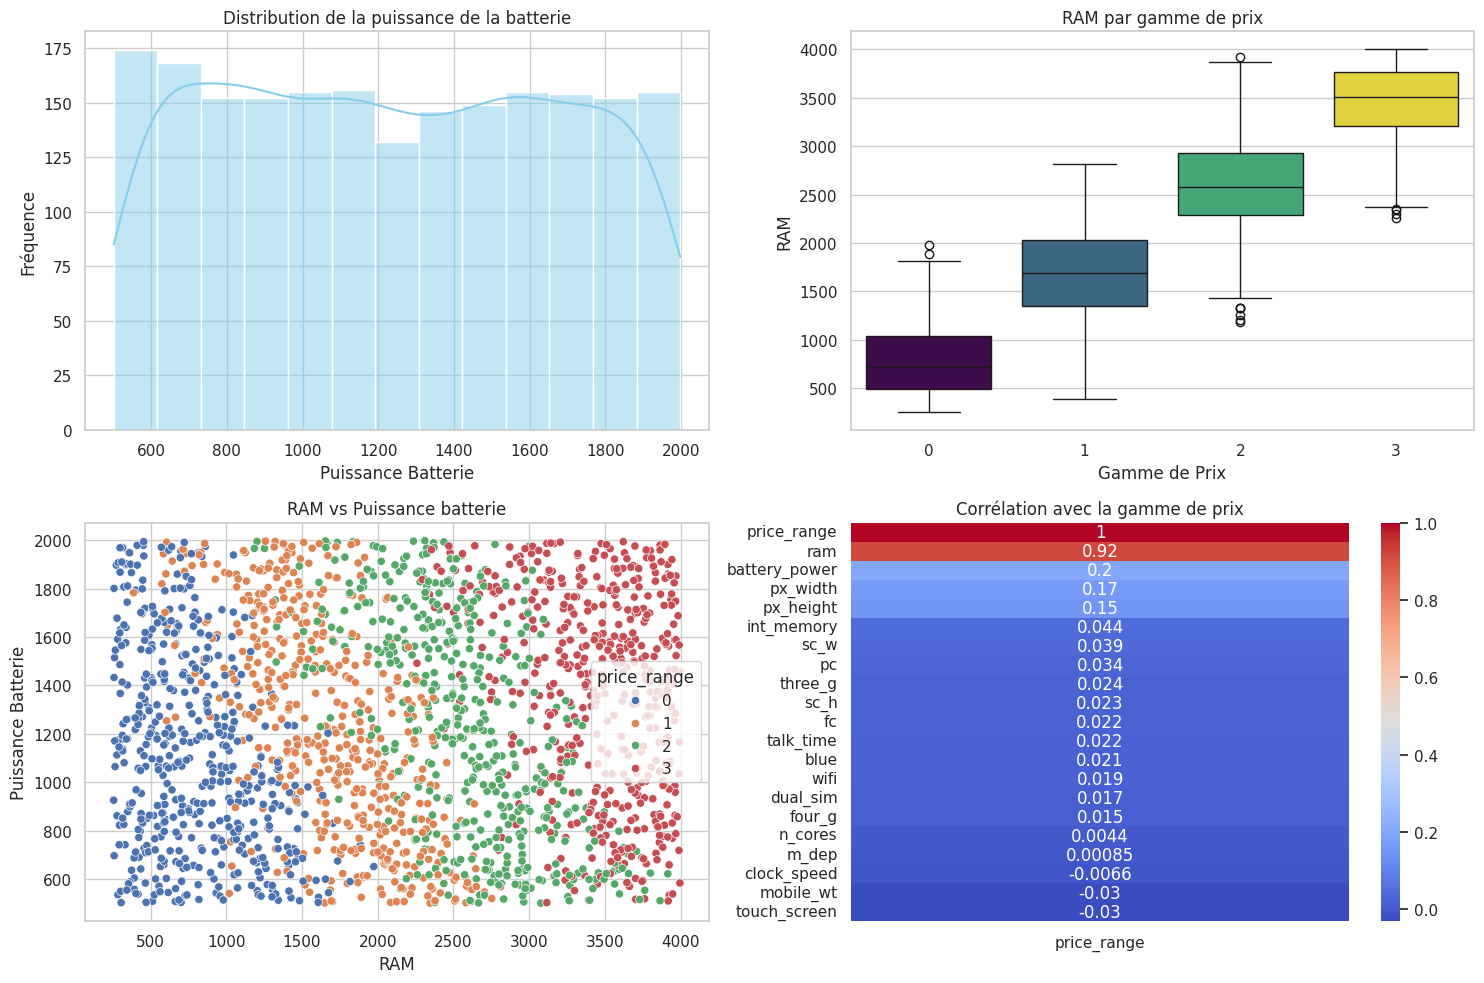

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

# Configuration du style
sns.set(style="whitegrid")
plt.figure(figsize=(15, 10))

# 1. Histogramme de la capacité de la batterie
plt.subplot(2, 2, 1)
sns.histplot(df['battery_power'], kde=True, color='skyblue')
plt.title('Distribution de la puissance de la batterie')
plt.xlabel('Puissance Batterie')
plt.ylabel('Fréquence')

# 2. Diagramme en boîte : RAM vs Price Range
plt.subplot(2, 2, 2)
# Correction de l'avertissement FutureWarning
sns.boxplot(x='price_range', y='ram', hue='price_range', data=df, palette='viridis', legend=False)
plt.title('RAM par gamme de prix')
plt.xlabel('Gamme de Prix')
plt.ylabel('RAM')

# 3. Nuage de points : RAM vs Battery Power coloré par Price Range
plt.subplot(2, 2, 3)
sns.scatterplot(x='ram', y='battery_power', hue='price_range', data=df, palette='deep')
plt.title('RAM vs Puissance batterie')
plt.xlabel('RAM')
plt.ylabel('Puissance Batterie')

# 4. Carte thermique (Heatmap) des corrélations
plt.subplot(2, 2, 4)
corr_matrix = df.corr()
sns.heatmap(corr_matrix[['price_range']].sort_values(by='price_range', ascending=False), annot=True, cmap='coolwarm')
plt.title('Corrélation avec la gamme de prix')

plt.tight_layout()
plt.show()

## 5. Synthèse des idées et conclusion
### Conclusions principales :
1. **RAM comme facteur clé** : L'analyse statistique et la visualisation montrent que la RAM est le principal moteur du prix (corrélation de 0.91).
2. **Signification statistique** : Le test ANOVA confirme que les différences de RAM entre les catégories de prix ne sont pas dues au hasard (p-value < 0.05).
3. **Distribution** : La plupart des caractéristiques comme la puissance de la batterie sont uniformément distribuées, ce qui suggère une gamme variée de spécifications.

En conclusion, pour prédire la catégorie de prix d'un mobile, la mémoire vive (RAM) est l'indicateur le plus fiable.